In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

In [2]:
df = pd.read_csv("2019.csv")
df.head()

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Overall rank                  156 non-null    int64  
 1   Country or region             156 non-null    object 
 2   Score                         156 non-null    float64
 3   GDP per capita                156 non-null    float64
 4   Social support                156 non-null    float64
 5   Healthy life expectancy       156 non-null    float64
 6   Freedom to make life choices  156 non-null    float64
 7   Generosity                    156 non-null    float64
 8   Perceptions of corruption     156 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory usage: 11.1+ KB


In [4]:
df.describe()

,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
count,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000
mean,78.500000,5.407096,0.905147,1.208814,0.725244,0.392571,0.184846,0.110603
std,45.177428,1.113120,0.398389,0.299191,0.242124,0.143289,0.095254,0.094538
min,1.000000,2.853000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,39.750000,4.544500,0.602750,1.055750,0.547750,0.308000,0.108750,0.047000
50%,78.500000,5.379500,0.960000,1.271500,0.789000,0.417000,0.177500,0.085500
75%,117.250000,6.184500,1.232500,1.452500,0.881750,0.507250,0.248250,0.141250
max,156.000000,7.769000,1.684000,1.624000,1.141000,0.631000,0.566000,0.453000


In [6]:
df.drop(['Country or region', 'Overall rank'], axis=1, inplace=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Score                         156 non-null    float64
 1   GDP per capita                156 non-null    float64
 2   Social support                156 non-null    float64
 3   Healthy life expectancy       156 non-null    float64
 4   Freedom to make life choices  156 non-null    float64
 5   Generosity                    156 non-null    float64
 6   Perceptions of corruption     156 non-null    float64
dtypes: float64(7)
memory usage: 8.7 KB


<Axes: xlabel='GDP per capita', ylabel='Score'>

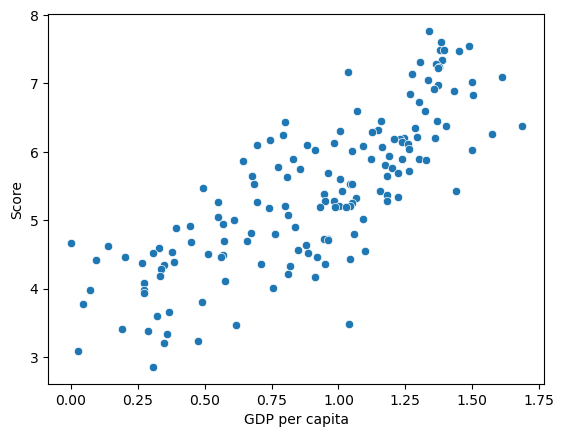

In [9]:
sns.scatterplot(x=df['GDP per capita'], y=df['Score'])

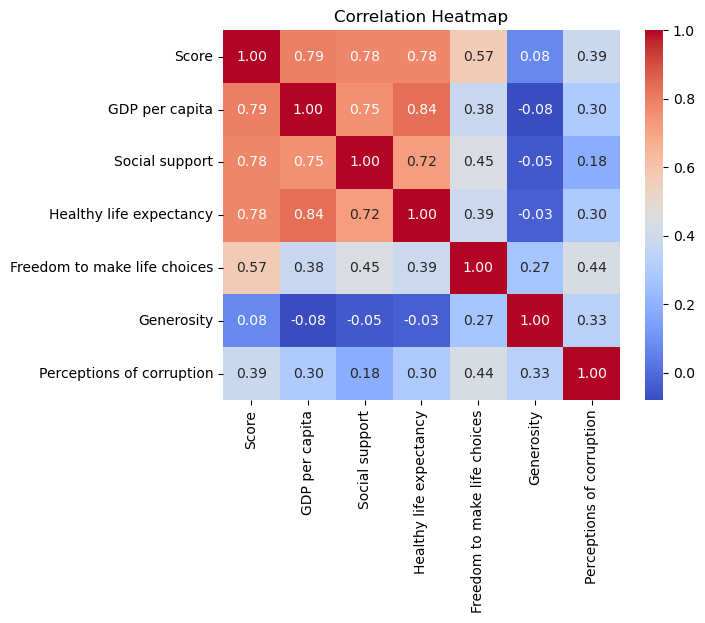

In [10]:
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [20]:
X = df.drop('Score', axis=1)
y = df['Score']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)
y_predict = lr.predict(X_test)
y_train_predict = lr.predict(X_train)

from sklearn.metrics import r2_score

print(r2_score(y_train, y_train_predict))
print(r2_score(y_test, y_predict))

0.815179955967481


0.6017537913445683

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)
y_predict = lr.predict(X_test_scaled)
y_train_predict = lr.predict(X_train_scaled)

print(r2_score(y_train, y_train_predict))
print(r2_score(y_test, y_predict))

0.815179955967481
0.6017537913445683


In [24]:
from sklearn.linear_model import Ridge

ridge = Ridge()

ridge.fit(X_train_scaled, y_train)
y_predict = ridge.predict(X_test_scaled)
y_train_predict = ridge.predict(X_train_scaled)

print(r2_score(y_train, y_train_predict))
print(r2_score(y_test, y_predict))

0.815172271910329
0.6019089110942532


In [28]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()

rf.fit(X_train_scaled, y_train)
y_predict = rf.predict(X_test_scaled)
y_train_predict = rf.predict(X_train_scaled)

print(r2_score(y_train, y_train_predict))
print(r2_score(y_test, y_predict))

0.9753200189799244
0.6133926535113128


In [29]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': range(1, 500, 100),
    'max_depth': range(1, 10),
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(RandomForestRegressor(), param_grid, cv=5)

grid.fit(X_train_scaled, y_train)

grid.best_params_, grid.best_score_

({'max_depth': 6, 'min_samples_split': 5, 'n_estimators': 101},
 np.float64(0.799333263651299))

In [30]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test_scaled)
y_train_pred = best_model.predict(X_train_scaled)
print("Train R²:", r2_score(y_train, y_train_pred))
print("Test R²:", r2_score(y_test, y_pred))

Train R²: 0.9561175845647436
Test R²: 0.6202916015212446


In [31]:
df['authority_index'] = (1-df['Freedom to make life choices']) * (1-df['Perceptions of corruption'])

In [32]:
df['quality_of_life'] = df['GDP per capita'] * df['Social support'] * df['Healthy life expectancy']

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

best_model = grid.best_estimator_
best_model.fit(X_train_scaled, y_train)
y_pred = best_model.predict(X_test_scaled)
y_train_pred = best_model.predict(X_train_scaled)
print("Train R²:", r2_score(y_train, y_train_pred))
print("Test R²:", r2_score(y_test, y_pred))

Train R²: 0.9565223369934034
Test R²: 0.636062562371389
